In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import MicroTools as micro
from MicroTools import plot_tools as pt
import MiniTools as mini
import MicroTools.param_scan as param_scan

from importlib.resources import open_text


In [2]:
dic_osc_full = param_scan.load_scan_data('fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl')

bf_osc_full = param_scan.get_best_fit_point(dic_osc_full)

In [3]:
def get_best_fit_point(dic, Umu4SQRmax=1, Ue4SQRmax=1, dm4SQRmin=1e-2):
    mask = (
        (dic["Umu4SQR"] < Umu4SQRmax)
        & (dic["Ue4SQR"] < Ue4SQRmax)
        & (dic["dm4SQR"] > dm4SQRmin)
    )
    argmin = np.argmin(dic["MicroApp_chi2"][mask])
    dic_best_fit = {}
    for key in dic.keys():
        if key == "Ue4SQR":
            new_key = "Ue4Sq"
        elif key == "Umu4SQR":
            new_key = "Um4Sq"
        else:
            new_key = key
        dic_best_fit[new_key] = dic[key][mask][argmin]
    return dic_best_fit

bf_osc_micro = get_best_fit_point(dic_osc_full)
bf_osc_micro['MicroApp_chi2']

np.float64(90.0096161966492)

In [4]:
bf_osc_full

{'g': np.float64(1e-10),
 'm4': np.float64(0.44984326689694454),
 'Ue4Sq': np.float64(0.018486873582389367),
 'Um4Sq': np.float64(0.5),
 'sin2theta': np.float64(0.036974),
 'dm4SQR': np.float64(0.20235896477251566),
 'MiniApp_chi2': np.float64(36.26918072449617),
 'MicroApp_chi2': np.float64(113.7536758714175),
 'MicroApp_Asimov_chi2': np.float64(14.501561272313172),
 'MiniApp_deltachi2': np.float64(0.0),
 'MicroApp_deltachi2': np.float64(23.744059674768295),
 'MicroApp_Asimov_deltachi2': np.float64(11.690719536619298)}

## MiniBooNE nu_e sample

In [5]:
# settings for Mini Figs
TOTAL_RATE = False
INCLUDE_MB_LAST_BIN = False
STACKED = False
PLOT_FAMILY=False
PATH_PLOTS = 'plots/event_rates/'

PAPER_TAG = r'HKZ\,2024'

In [6]:
Weight_nue_flux = mini.apps.reweight_MC_to_nue_flux(
            param_scan.Etrue_nue, param_scan.Weight_nue, mode="fhc"
        )

MC_nue_bkg_intrinsic = np.dot(
                param_scan.fast_histogram(
                    param_scan.Etrue_nue, bins=param_scan.e_prod_e_int_bins, weights=Weight_nue_flux
                )[0],
                mini.apps.migration_matrix_official_bins_nue_11bins,
            )

In [8]:
import scipy
from scipy.stats import norm
def get_pval(rates_dic, ndof=8.7):
    MB_chi2 = mini.fit.chi2_MiniBooNE_combined(
                MC_nue_app=rates_dic["MC_nue_app"],
                MC_nuebar_app=rates_dic["MC_nuebar_app"],
                MC_nue_dis=rates_dic["MC_nue_bkg_total_w_dis"],
                MC_numu_dis=rates_dic["MC_numu_bkg_total_w_dis"],
                MC_nuebar_dis=rates_dic["MC_nuebar_bkg_total_w_dis"],
                MC_numubar_dis=rates_dic["MC_numubar_bkg_total_w_dis"],
                year="2020",
            )
    return scipy.stats.chi2.sf(MB_chi2, ndof)


def get_pval_nu(rates_dic, ndof=8.7):
    MB_chi2 = mini.fit.chi2_MiniBooNE_combined(
                MC_nue_app=rates_dic["MC_nue_app"],
                MC_nue_dis=rates_dic["MC_nue_bkg_total_w_dis"],
                MC_numu_dis=rates_dic["MC_numu_bkg_total_w_dis"],
                year="2020",
            )
    return scipy.stats.chi2.sf(MB_chi2, ndof)

In [9]:
def make_rate_plot(rates, params, name='3+1_osc'):
    fig, ax1 = pt.std_fig(figsize=(3.3*1.2,2.3*1.2))
    bins = param_scan.MB_Ereco_official_bins
    bin_w = np.diff(bins)
    bin_c = bins[:-1] + bin_w/2

    ######################################
    # MiniBooNE 
    if TOTAL_RATE:
        units= 1
        ax1.set_ylabel(r"Events")
    else:
        units = 1/micro.bin_width
        ax1.set_ylabel(r"Events/MeV")

    nue_data = np.genfromtxt(
        open_text(
            f"MiniTools.include.MB_data_release_2020.combined",
            f"miniboone_nuedata_lowe.txt",
        )
    )
    nue_tot_bkg = np.genfromtxt(
                open_text(
                    f"MiniTools.include.MB_data_release_2020.combined",
                    f"miniboone_nuebgr_lowe.txt",
                )
            )
    nue_bkg_midID = nue_tot_bkg - MC_nue_bkg_intrinsic

    # plot data
    pt.data_plot(ax1, 
            X=bin_c,
            Y=nue_data*units, 
            xerr=bin_w/2, 
            yerr=np.sqrt(nue_data)*units,
            zorder=3)


    ax1.hist(bins[:-1],
            bins=bins,
            weights=(nue_tot_bkg)*units,
            edgecolor='black',
            lw=0.5,
            ls=(1,(2,1)),
            label=r'unoscillated total bkg',
            histtype='step',
            zorder=1.6)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(nue_bkg_midID)*units,
            edgecolor='black',
            facecolor='lightgrey',
            lw=0.5,
            label=r'misID bkg',
            histtype='stepfilled',
            zorder=2)
    ax1.hist(bins[:-1],
            bins=bins,
            # weights=(nue_tot_bkg)*units,
            weights=rates['MC_nue_bkg_total_w_dis']*units,
            edgecolor='black',
            facecolor='peachpuff',
            lw=0.5,
            label=r'$\nu_e$ disappearance',
            histtype='stepfilled',
            zorder=1.6)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(rates['MC_nue_app'] + rates['MC_nue_bkg_total_w_dis'])*units,
            # weights=(rates_dic_osc['MC_nue_app'] + nue_tot_bkg)*units,
            edgecolor='black',
            facecolor='lightblue',
            lw=0.5,
            linestyle=(1,(3,0)),
            label=r'$\nu_\mu \to \nu_e$ appearance',
            histtype='stepfilled',
            zorder=1.5)



    ax1.legend(fontsize=8, markerfirst=False, ncol=1)
    pval = r'$p_{\rm val}$'
    pval_str = fr'{pval} $\,= {get_pval(rates, 38-5)*100:.3f}\%$'
    #ax1.annotate(text=r'MiniBooNE FHC 2020 -- '+ pval_str, xy=(0.0,1.025), xycoords='axes fraction', fontsize=9)
    ax1.annotate(text=r'MiniBooNE FHC 2020', xy=(0.0,1.025), xycoords='axes fraction', fontsize=9)
    ax1.annotate(text=rf'\noindent $\Delta m^2 = {params["m4"]**2:.2f}$ eV$^2$\\$|U_{{e4}}|^2 = {params["Ue4Sq"]:.2f}$\\$|U_{{\mu 4}}|^2 = {params["Um4Sq"]:.4f}$', 
                 xy=(0.65,0.45), 
                 xycoords='axes fraction', 
                 fontsize=8.5,
                 bbox=dict(facecolor='none', edgecolor='black', linewidth=0.5, boxstyle='square,pad=0.3'),
                 multialignment='left')
    ax1.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
    if INCLUDE_MB_LAST_BIN:
        ax1.set_xticks([0.2,0.5,1,1.5,2,2.5,3])
        ax1.set_xlim(0.2,3)
    else:
        ax1.set_xticks([0.2,0.4,0.6,0.8,1,1.2,1.4])
        ax1.set_xlim(0.2,1.5)
    ax1.set_ylim(0,8)
    # ax1.xaxis.set_major_locator(pt.MultipleLocator(0.5))
    # ax1.xaxis.set_minor_locator(pt.MultipleLocator(0.1))
    #print(rates['MC_nue_bkg_total_w_dis'])

    # ax1.annotate(text=PAPER_TAG, xy=(1,1.025), xycoords='axes fraction', fontsize=8.5, ha='right')
    ax1.annotate(text=fr'{pval} $\,= {get_pval(rates, 38-5)*100:.1f}\%$', xy=(0.15,0.9), xycoords='axes fraction', fontsize=8.5)
    # fig.savefig(f"{PATH_PLOTS}/Mini_{name}.png", dpi=400)
    fig.savefig(f"{PATH_PLOTS}/Mini_{name}.pdf", dpi=400)

/var/folders/b5/dychg4352v56vffff0s9pqpw0000gn/T/ipykernel_16445/3933024098.py:17: DeprecationWarning: open_text is deprecated. Use files() instead. Refer to https://importlib-resources.readthedocs.io/en/latest/using.html#migrating-from-legacy for migration advice.
  open_text(
/var/folders/b5/dychg4352v56vffff0s9pqpw0000gn/T/ipykernel_16445/3933024098.py:23: DeprecationWarning: open_text is deprecated. Use files() instead. Refer to https://importlib-resources.readthedocs.io/en/latest/using.html#migrating-from-legacy for migration advice.
  open_text(


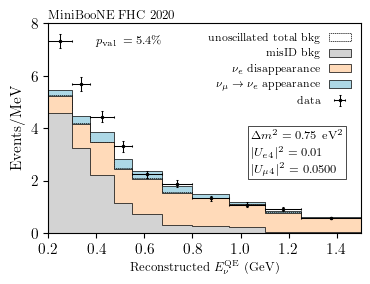

In [10]:
params_test = {'g': 1e-10, 'Ue4Sq': 0.01, 'Um4Sq': 0.05, 'm4': np.sqrt(0.754)}
rates_dic_osc_test = param_scan.get_nue_rates(params_test, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)
rates_dic_decay_test = param_scan.get_nue_rates(params_test, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=True, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=10, undo_numu_normalization=False)
make_rate_plot(rates_dic_osc_test, params_test, '3+1_osc_test')

/var/folders/b5/dychg4352v56vffff0s9pqpw0000gn/T/ipykernel_16445/3933024098.py:17: DeprecationWarning: open_text is deprecated. Use files() instead. Refer to https://importlib-resources.readthedocs.io/en/latest/using.html#migrating-from-legacy for migration advice.
  open_text(
/var/folders/b5/dychg4352v56vffff0s9pqpw0000gn/T/ipykernel_16445/3933024098.py:23: DeprecationWarning: open_text is deprecated. Use files() instead. Refer to https://importlib-resources.readthedocs.io/en/latest/using.html#migrating-from-legacy for migration advice.
  open_text(


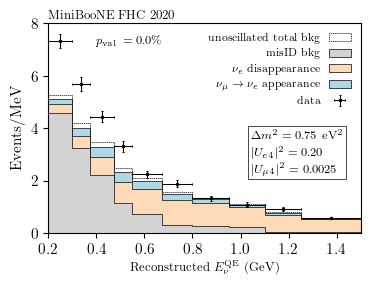

In [11]:
params_test = {'g': 1e-10, 'Ue4Sq': 0.2, 'Um4Sq': 0.0025, 'm4': np.sqrt(0.754)}
rates_dic_osc_test = param_scan.get_nue_rates(params_test, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)
make_rate_plot(rates_dic_osc_test, params_test, '3+1_osc_test_1')

## MicroBooNE Rates

In [12]:
from MicroTools.InclusiveTools.inclusive_osc_tools import (
    Decay_muB_OscChi2,
    DecayMuBNuMuDis,
    DecayMuBNuEDis,
)

In [32]:
import copy
def make_micro_rate_plot(rates_osc, params, name='micro_3+1_osc', PC=False, helicity = 'conserving'):
    fig, ax1 = pt.std_fig(figsize=(3.3*1.2,2.3*1.2))

    bins = np.array([0.0 + 0.1 * j for j in range(26)] + [10.0])
    bin_w = np.diff(bins)
    bin_c = bins[:-1] + bin_w/2


    # oscillation only MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
    uBFC_osc = param_scan.GBFC.miniToMicro(rates_osc["MC_nue_app_for_unfolding"])
    uBFC_osc = np.insert(uBFC_osc, 0, [0.0])
    uBFC_osc = np.append(uBFC_osc, 0.0)

    # MicroBooNE partially inclusive signal by unfolding MiniBooNE Signal
    MC_nue_app_for_unfolding2_osc = copy.deepcopy(rates_osc["MC_nue_app_for_unfolding"])
    uBPC_osc = param_scan.GBPC.miniToMicro(MC_nue_app_for_unfolding2_osc)
    uBPC_osc = np.insert(uBPC_osc, 0, [0.0])
    uBPC_osc = np.append(uBPC_osc, 0.0)

    uBtemp_osc = np.concatenate([uBFC_osc, uBPC_osc, np.zeros(85)])

    uB_signal_osc = uBPC_osc if PC else uBFC_osc

#     unfolding = micro.unfolder.MBtomuB(
#     analysis="1eX_PC" if PC else "1eX",
#     remove_high_energy=False,
#     unfold=True,
#     effNoUnfold=True,
#     which_template="2020",
#     )

    # MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
#     uB_signal = unfolding.miniToMicro(rates["MC_nue_app_for_unfolding"])
#     uB_signal = np.insert(uB_signal, 0, [0.0])
#     uB_signal = np.append(uB_signal, 0.0)

    SAMPLE = "PC" if PC else "FC"
    other_bkg = np.load(micro.muB_inclusive_datarelease_path + f'nueCC_{SAMPLE}_Bkg.npy')
    intrinsic_bkg = np.load(micro.muB_inclusive_datarelease_path + f'nueCC_{SAMPLE}_Sig.npy')
    data = np.load(micro.muB_inclusive_datarelease_path + f'nueCC_{SAMPLE}_Obs.npy')

    # \nu_e disappearance signal replacement (oscillation term -- lightgreen)
    NuEReps = DecayMuBNuEDis(
    params,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    NuERepsOsc = DecayMuBNuEDis(
        params,
        oscillations=True,
        decay=False,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    # \nu_mu disappearance signal replacement
    
    NuMuReps = DecayMuBNuMuDis(
    params,
    oscillations=True,
    decay=True,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    # MicroBooNE
    MuB_chi2 = Decay_muB_OscChi2(
        params,
        uBtemp_osc,
        constrained=False,
        sigReps=[NuEReps[0], NuEReps[1], NuMuReps[0], NuMuReps[1], None, None, None],
        RemoveOverflow=True,
        oscillations=True,
        decay=False,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    ###################################### 
    if TOTAL_RATE:
        units= 1
        ax1.set_ylabel(r"Events")
    else:
        units = 1/bin_w/1e3
        ax1.set_ylabel(r"Events/MeV")

    # plot data
    pt.data_plot(ax1, 
            X=bin_c,
            Y=data*units, 
            xerr=bin_w/2, 
            yerr=np.sqrt(data)*units,
            zorder=3)

    
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(other_bkg + intrinsic_bkg)*units,
            edgecolor='black',
            lw=0.5,
            ls=(1,(2,1)),
            label=r'unoscillated total bkg',
            histtype='step',
            zorder=1.8)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=other_bkg*units,
            edgecolor='black',
            facecolor='lightgrey',
            lw=0.5,
            label=r'Non-$\nu_e$ bkg',
            histtype='stepfilled',
            zorder=1.7)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(other_bkg+NuEReps[1 if PC else 0])*units,
            edgecolor='black',
            facecolor='peachpuff',
            lw=0.5,
            label=r'$\nu_e$ disappearance',
            histtype='stepfilled',
            zorder=1.6)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(other_bkg+uB_signal_osc+NuEReps[1 if PC else 0])*units,
            edgecolor='black',
            facecolor='lightblue',
            lw=0.5,
            label=r'$\nu_e$ appearance',
            histtype='stepfilled',
            zorder=1.4)

    ax1.legend(loc='upper right', fontsize=8, markerfirst=False, ncol=1)
    ax1.annotate(text=fr'MicroBooNE {"PC" if PC else "FC"} 2020 {"Helicity--Flipping" if helicity == "flipping" else ""}', xy=(0.0,1.025), xycoords='axes fraction', fontsize=9)
    ax1.annotate(text=rf'\noindent $\Delta m^2 = {params["m4"]**2:.2f}$ eV$^2$\\$|U_{{e4}}|^2 = {params["Ue4Sq"]:.2f}\\|U_{{\mu 4}}|^2 = {params["Um4Sq"]:.4f}$', 
                 xy=(0.025,0.91), 
                 xycoords='axes fraction', 
                 fontsize=8.5,
                 bbox=dict(facecolor='none', edgecolor='black', linewidth=0.5, boxstyle='square,pad=0.3'))

    ax1.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
    ax1.set_xticks([0,0.5,1.0,1.5,2.0, 2.5])
    ax1.set_xlim(0.0,2.5)
    ax1.set_ylim(0,0.3 if PC else 0.5)

    ax1.annotate(text='$\Delta \chi^2=$%.2f'%(MuB_chi2-bf_osc_micro['MicroApp_chi2']), xy=(1,1.025), xycoords='axes fraction', fontsize=8.5, ha='right')

#     fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.png", dpi=400)
    fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.pdf", dpi=400)

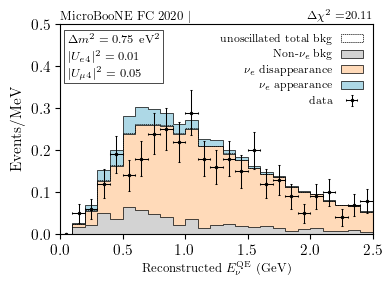

In [18]:
params_test = {'g': 1e-10, 'Ue4Sq': 0.01, 'Um4Sq': 0.05, 'm4': np.sqrt(0.754)}
rates_dic_osc_test = param_scan.get_nue_rates(params_test, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=False, n_replications=1, undo_numu_normalization=False)
make_micro_rate_plot(rates_dic_osc_test, params_test, 'test') 

In [19]:
from scipy.stats import chi2
confidence_level = 0.95

dof = 2

chi2_value = chi2.ppf(confidence_level, dof)

print(f"Chi-squared value for 95% confidence level with {dof} degrees of freedom: {chi2_value}")

Chi-squared value for 95% confidence level with 2 degrees of freedom: 5.991464547107979


In [25]:
# Numu data
NuMuCC_TrueEDist_FC = np.loadtxt(f"{muB_inclusive_data_path}/TrueEDist_numuCC_FC.dat")
NuMuCC_MigMat_FC = np.loadtxt(f"{muB_inclusive_data_path}/MigMat_numuCC_FC.dat")
NuMuCC_Eff_FC = np.loadtxt(f"{muB_inclusive_data_path}/Efficiency_numuCC_FC.dat")

NuMuCC_TrueEDist_PC = np.loadtxt(f"{muB_inclusive_data_path}/TrueEDist_numuCC_PC.dat")
NuMuCC_MigMat_PC = np.loadtxt(f"{muB_inclusive_data_path}/MigMat_numuCC_PC.dat")
NuMuCC_Eff_PC = np.loadtxt(f"{muB_inclusive_data_path}/Efficiency_numuCC_PC.dat")

RecoDist_FC_0 = np.dot(NuMuCC_MigMat_FC, NuMuCC_TrueEDist_FC)
RecoDist_PC_0 = np.dot(NuMuCC_MigMat_PC, NuMuCC_TrueEDist_PC)

RecoDist_FC = []
RecoDist_PC = []
for j in range(25):
    RecoDist_FC.append(0.5 * (RecoDist_FC_0[2 * j] + RecoDist_FC_0[2 * j + 1]))
    RecoDist_PC.append(0.5 * (RecoDist_PC_0[2 * j] + RecoDist_PC_0[2 * j + 1]))
RecoDist_FC.append(np.sum(RecoDist_FC_0[50:]))
RecoDist_PC.append(np.sum(RecoDist_PC_0[50:]))

NuMubkgFC = [RecoDist_FC[kk] * NuMuCC_Eff_FC[kk] for kk in range(len(NuMuCC_Eff_FC))]
NuMubkgPC = [RecoDist_PC[kk] * NuMuCC_Eff_PC[kk] for kk in range(len(NuMuCC_Eff_PC))]
NuMubkg = [NuMubkgFC, NuMubkgPC]


In [28]:
import copy
from MicroTools import muB_inclusive_data_path
def make_micro_rate_plot_numu(rates_osc, params, name='micro_3+1_osc', PC=False, helicity = 'conserving'):
    fig, ax1 = pt.std_fig(figsize=(3.3*1.2,2.3*1.2))

    bins = np.array([0.0 + 0.1 * j for j in range(26)] + [10.0])
    bin_w = np.diff(bins)
    bin_c = bins[:-1] + bin_w/2



    # oscillation only MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
    uBFC_osc = param_scan.GBFC.miniToMicro(rates_osc["MC_nue_app_for_unfolding"])
    uBFC_osc = np.insert(uBFC_osc, 0, [0.0])
    uBFC_osc = np.append(uBFC_osc, 0.0)

    # MicroBooNE partially inclusive signal by unfolding MiniBooNE Signal
    MC_nue_app_for_unfolding2_osc = copy.deepcopy(rates_osc["MC_nue_app_for_unfolding"])
    uBPC_osc = param_scan.GBPC.miniToMicro(MC_nue_app_for_unfolding2_osc)
    uBPC_osc = np.insert(uBPC_osc, 0, [0.0])
    uBPC_osc = np.append(uBPC_osc, 0.0)

    uBtemp_osc = np.concatenate([uBFC_osc, uBPC_osc, np.zeros(85)])

    uB_signal_osc = uBPC_osc if PC else uBFC_osc

#     unfolding = micro.unfolder.MBtomuB(
#     analysis="1eX_PC" if PC else "1eX",
#     remove_high_energy=False,
#     unfold=True,
#     effNoUnfold=True,
#     which_template="2020",
#     )

    # MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
#     uB_signal = unfolding.miniToMicro(rates["MC_nue_app_for_unfolding"])
#     uB_signal = np.insert(uB_signal, 0, [0.0])
#     uB_signal = np.append(uB_signal, 0.0)

    SAMPLE = "PC" if PC else "FC"
    other_bkg = np.load(micro.muB_inclusive_datarelease_path + f'nueCC_{SAMPLE}_Bkg.npy')
    intrinsic_bkg = np.load(micro.muB_inclusive_datarelease_path + f'nueCC_{SAMPLE}_Sig.npy')
    data = np.load(micro.muB_inclusive_datarelease_path + f'nueCC_{SAMPLE}_Obs.npy')

    # \nu_e disappearance signal replacement (oscillation term -- lightgreen)
    NuEReps = DecayMuBNuEDis(
    params,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    # \nu_e disappearance signal replacement (include regeneration term -- lightskyblue)
    NuERepsRegen = DecayMuBNuEDis(
    params,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    NuERepsOsc = DecayMuBNuEDis(
        params,
        oscillations=True,
        decay=False,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    # \nu_mu disappearance signal replacement
    
    NuMuReps = DecayMuBNuMuDis(
    params,
    oscillations=True,
    decay=True,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    # MicroBooNE
    MuB_chi2 = Decay_muB_OscChi2(
        params,
        uBtemp_osc,
        constrained=False,
        sigReps=[NuEReps[0], NuEReps[1], NuMuReps[0], NuMuReps[1], None, None, None],
        RemoveOverflow=True,
        oscillations=True,
        decay=True,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    ###################################### 
    if TOTAL_RATE:
        units= 1
        ax1.set_ylabel(r"Events")
    else:
        units = 1/bin_w/1e3
        ax1.set_ylabel(r"Events/MeV")

    # # plot data
    # pt.data_plot(ax1, 
    #         X=bin_c,
    #         Y=data*units, 
    #         xerr=bin_w/2, 
    #         yerr=np.sqrt(data)*units,
    #         zorder=3)

    #ax1.hist(bins[:-1],
            #bins=bins,
            #weights=(other_bkg+NuERepsRegen[1 if PC else 0])*units,
            #edgecolor='black',
            #facecolor='lightskyblue',
            #lw=0.5,
            #label=r'$\nu_e$ regeneration',
            #histtype='stepfilled',
            #zorder=1.6)    
    
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(NuMubkg[1 if PC else 0])*units,
            edgecolor='black',
            lw=0.5,
            ls=(1,(2,1)),
            label=r'unoscillated total bkg',
            histtype='step',
            zorder=1.8)
            
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(NuMuReps[1 if PC else 0])*units,
            edgecolor='black',
            facecolor='peachpuff',
            lw=0.5,
            label=r'$\nu_\mu$ disappearance',
            histtype='stepfilled',
            zorder=1.6)

    ax1.legend(loc='upper right', fontsize=8, markerfirst=False, ncol=1)
    ax1.annotate(text=fr'MicroBooNE {"PC" if PC else "FC"} 2020  {"Helicity--Flipping" if helicity == "flipping" else ""}', xy=(0.0,1.025), xycoords='axes fraction', fontsize=9)
    ax1.annotate(text=rf'\noindent $\Delta m^2 = {params["m4"]**2:.2f}$ eV$^2$\\$|U_{{e4}}|^2 = {params["Ue4Sq"]:.2f}\\|U_{{\mu 4}}|^2 = {params["Um4Sq"]:.4f}$', 
                 xy=(0.70,0.25), 
                 xycoords='axes fraction', 
                 fontsize=8.5,
                 bbox=dict(facecolor='none', edgecolor='black', linewidth=0.5, boxstyle='square,pad=0.3'))

    ax1.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
    ax1.set_xticks([0,0.5,1.0,1.5,2.0, 2.5])
    ax1.set_xlim(0.0,2.5)
    ax1.set_ylim(0,45)

    ax1.annotate(text='$\Delta \chi^2=$%.2f'%(MuB_chi2-bf_osc_micro['MicroApp_chi2']), xy=(1,1.025), xycoords='axes fraction', fontsize=8.5, ha='right')

#     fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.png", dpi=400)
    fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.pdf", dpi=400)

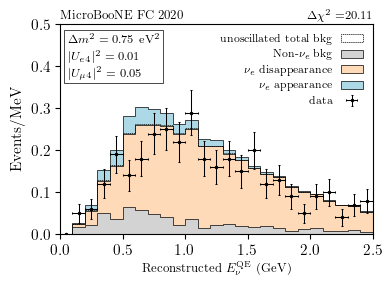

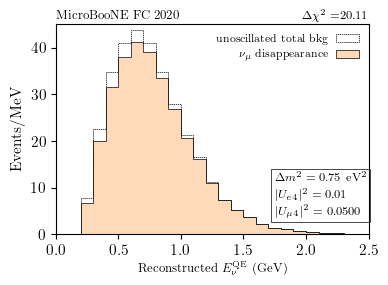

In [29]:
params_test = {'g': 1e-10, 'Ue4Sq': 0.01, 'Um4Sq': 0.05, 'm4': np.sqrt(0.754)}
rates_dic_osc_test = param_scan.get_nue_rates(params_test, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)
make_micro_rate_plot(rates_dic_osc_test, params_test, 'test')
make_micro_rate_plot_numu(rates_dic_osc_test, params_test, 'test_numu') 

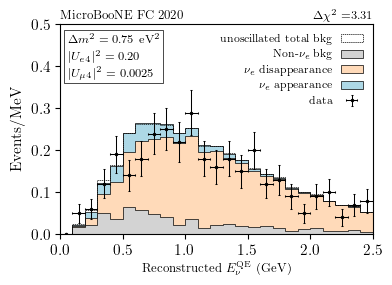

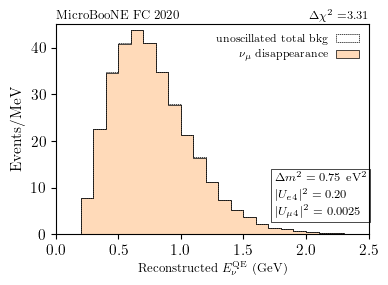

In [33]:
params_test = {'g': 1e-10, 'Ue4Sq': 0.2, 'Um4Sq': 0.0025, 'm4': np.sqrt(0.754)}
rates_dic_osc_test = param_scan.get_nue_rates(params_test, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)
make_micro_rate_plot(rates_dic_osc_test, params_test, 'test_1')
make_micro_rate_plot_numu(rates_dic_osc_test, params_test, 'test_numu_1') 

3D slice

In [39]:
import numpy as np
import matplotlib.pyplot as plt

import MicroTools as micro
import MicroTools.plot_tools as pt

import MicroTools.param_scan as param_scan
import uproot

from scipy.stats import chi2
levels_sigmas_2dof = [chi2.ppf(0.682689492137086, 2), chi2.ppf(0.954499736103642, 2), chi2.ppf(0.997300203936740, 2), chi2.ppf(0.999936657516334, 2)]
levels_sigmas_3dof = [chi2.ppf(0.682689492137086, 3), chi2.ppf(0.954499736103642, 3), chi2.ppf(0.997300203936740, 3), chi2.ppf(0.999936657516334, 3)]
level_95CL_2dof = [chi2.ppf(0.95, 2)]
level_95CL_3dof = [chi2.ppf(0.95, 3)]
print(chi2.ppf(0.95, 2))
print(chi2.ppf(0.97, 2))

5.991464547107979
7.013115794639961


In [45]:
def load_scan_data(filename):
    data = param_scan.pickle_read(filename)
    
    data_dic = {}
    data_dic['Ue4SQR'] = data[:,2]
    data_dic['Umu4SQR'] = data[:,3]
    s2t = 4*data_dic['Ue4SQR']*data_dic['Umu4SQR']
    data_dic['sin2theta'] = np.round(s2t, decimals=6)
    data_dic['dm4SQR'] = data[:,1]**2
    
    data_dic['MiniApp_chi2'] =  data[:,-3]
    data_dic['MicroApp_chi2'] =  data[:,-2]
    data_dic['MicroApp_Asimov_chi2'] = data[:,-1] 

    data_dic['MiniApp_deltachi2'] = data_dic['MiniApp_chi2'] - np.min(data_dic['MiniApp_chi2'])
    data_dic['MicroApp_deltachi2'] = data_dic['MicroApp_chi2'] - np.min(data_dic['MicroApp_chi2'])
    data_dic['MicroApp_Asimov_deltachi2'] = data_dic['MicroApp_Asimov_chi2'] - np.min(data_dic['MicroApp_Asimov_chi2'])

    return data_dic

# Load Mini and Micro fits
data_dic = load_scan_data('fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl')

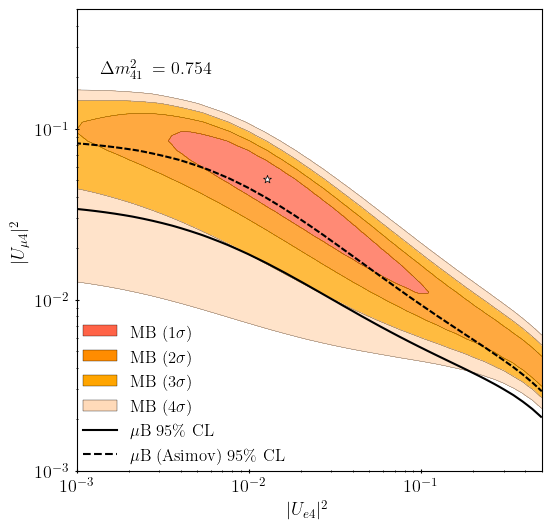

In [46]:
import numpy as np
import matplotlib.pyplot as plt

labels_slices = [r'$g_\varphi$', r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
string_slices = [r'$g_\varphi$', r'$\Delta m_{41}^2$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]

def get_var(data, i):
    if i == 1:
        return data[:, 1]**2
    return data[:, i]

def plot_single_slice(filename, xi=2, yi=3, zi=1, global_deltachi2=False, z_slice=0.754):
    data = param_scan.pickle_read(f"fit_data/fits_before_May6/{filename}.pkl")
    
    MiniApp_chi2, MicroApp_chi2, MicroApp_Asimov_chi2 = data[:, -3], data[:, -2], data[:, -1]
    MiniApp_deltachi2 = MiniApp_chi2 - np.min(MiniApp_chi2)
    MicroApp_deltachi2 = MicroApp_chi2 - np.min(MicroApp_chi2)
    MicroApp_Asimov_deltachi2 = MicroApp_Asimov_chi2 - np.min(MicroApp_Asimov_chi2)

    x, y, z = get_var(data, xi), get_var(data, yi), get_var(data, zi)
    i_min = np.argmin(MiniApp_deltachi2)
    x_min, y_min, z_min = x[i_min], y[i_min], z[i_min]

    # Find the closest slice to the true value
    z_slice_true = z[np.argmin(np.abs(z - z_slice))]
    cut = (z == z_slice_true)

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis="both", which='both', direction="inout", left="off", labelleft="on", zorder=10, labelsize=13)

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())

    ax.set_ylabel(string_slices[yi], fontsize=13)
    ax.set_xlabel(string_slices[xi], fontsize=13)

    ax.annotate(text=fr"{string_slices[zi]} $\,= {z_slice_true:.3f}$", 
                xycoords='axes fraction', 
                xy=(0.05, 0.86), 
                fontsize=13, 
                bbox=dict(facecolor='white', edgecolor='None', alpha=0.9, boxstyle='round'))

    kwargs_interp = {
        'fine_gridx': len(np.unique(x)),
        'fine_gridy': len(np.unique(y)),
        'logx': True,
        'logy': True,
        'method': 'triangulation'
    }

    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut] - np.min(MiniApp_chi2), **kwargs_interp)
        MB_levels = levels_sigmas_3dof
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut] - np.min(MiniApp_chi2[cut]), **kwargs_interp)
        MB_levels = levels_sigmas_2dof

    cs = ax.contourf(X, Y, Z, levels=[0] + MB_levels, colors=['tomato', 'darkorange', 'orange', 'peachpuff'], zorder=1, alpha=0.75)
    cs = ax.contour(X, Y, Z, levels=MB_levels, colors=['black', 'black', 'black', 'black'], linewidths=0.25, zorder=1, alpha=0.75)
    ax.scatter(X.flatten()[np.argmin(Z)], Y.flatten()[np.argmin(Z)], marker='*', facecolor='white', edgecolor='black', lw=0.5, zorder=10)

    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2), **kwargs_interp)
        level_MicroBooNE = level_95CL_3dof
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2[cut]), **kwargs_interp)
        level_MicroBooNE = level_95CL_2dof
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=['black'], zorder=2)

    if global_deltachi2:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2), **kwargs_interp)
    else:
        X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2[cut]), **kwargs_interp)
    cs = ax.contour(X, Y, Z, levels=level_MicroBooNE, colors=['black'], linestyles=[(1, (3, 1))], zorder=2)

    if z_min == z_slice:
        ax.scatter(x_min, y_min, marker='*', facecolor='black', edgecolor='black', lw=0.25, zorder=10)

    ax.fill([], [], edgecolor='black', facecolor='tomato', lw=0.25, label='MB ($1 \sigma$)')
    ax.fill([], [], edgecolor='black', facecolor='darkorange', lw=0.25, label='MB ($2 \sigma$)')
    ax.fill([], [], edgecolor='black', facecolor='orange', lw=0.25, label='MB ($3 \sigma$)')
    ax.fill([], [], edgecolor='black', facecolor='peachpuff', lw=0.25, label='MB ($4 \sigma$)')
    ax.plot([], [], color='black', lw=1.5, label='$\mu$B 95\% CL')
    ax.plot([], [], color='black', lw=1.5, ls='--', label='$\mu$B (Asimov) 95\% CL')
    ax.legend(loc=(0, 0), fontsize=12)

    fig.savefig(f"{micro.path_plots}/Micro_single_slice_{xi}_{yi}_{zi}{'_global' if global_deltachi2 else ''}.pdf", bbox_inches='tight', dpi=300)

# Example usage
plot_single_slice('MH_numu_MC_keep_numu_norm', xi=2, yi=3, zi=1, global_deltachi2=False, z_slice=0.754)